PARTIE 1 - CONSTRUCTION DU DATASET


1.1 Chargement






In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

data = yf.download("SPY", start="2015-01-01", end="2023-01-01")
data = data[['Close', 'Volume']]
data.dropna(inplace=True)

/tmp/ipykernel_3679/4111843617.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


1.2)Fonctions de features

In [2]:
def build_features(df):
    df = df.copy()

    # Rendement
    df['return'] = df['Close'].pct_change()

    # Volatilité (écart-type sur 5 jours)
    df['volatility'] = df['return'].rolling(window=5).std()

    # Moyenne mobile
    df['ma'] = df['Close'].rolling(window=5).mean()

    # Momentum (différence avec prix il y a 5 jours)
    df['momentum'] = df['Close'] - df['Close'].shift(5)

    # Variation du volume
    df['volume_change'] = df['Volume'].pct_change()

    return df

1.3 Fonction target

In [3]:
def build_target(df):
    df = df.copy()

    # 1 si le rendement futur est positif
    df['target'] = (df['Close'].pct_change().shift(-1) > 0).astype(int)

    return df

1.4 Pipeline complet

1) On utilise .shift(-1) pour accéder à l'information future (le rendement à t+1).
2)si on ne le fait on aua pas accès au jour suivant
3) Fuite d’information (data leakage)

4)le modèle devient artificiellement performant mais en réalité il est inutile en vrai

PARTIE 2 — ANALYSE DES DONNÉES

2.1 Visualisation


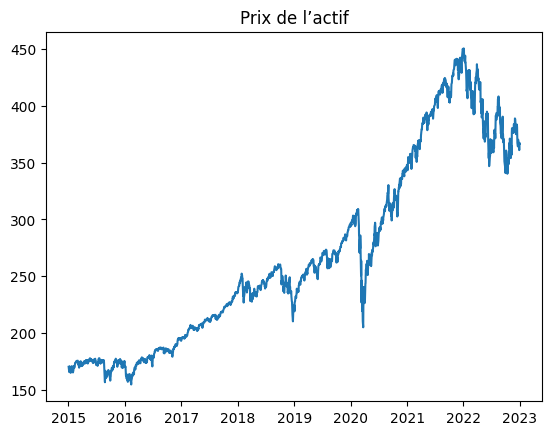

In [4]:
df = data.copy()
df = build_features(df)
df = build_target(df)

plt.plot(df['Close'])
plt.title("Prix de l’actif")
plt.show()

2.2 Distribution

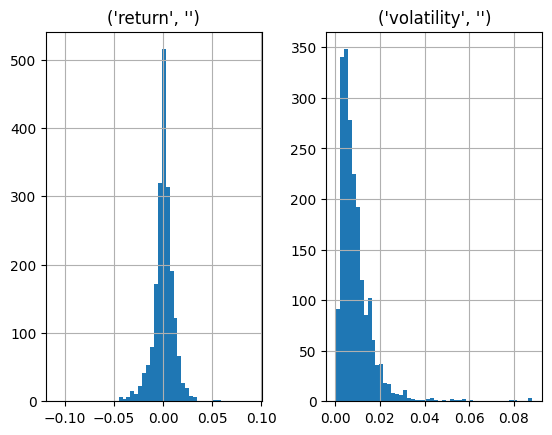

In [5]:
df[['return', 'volatility']].hist(bins=50)
plt.show()

2.3 Corrélations


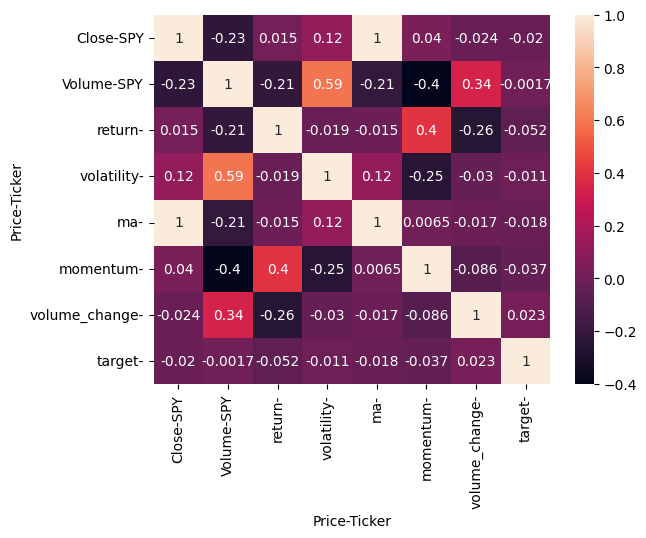

In [7]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()


Questions avancées
1. Non

Corrélations faibles

aucune variable ne prédit fortement la target

2)Non

Le problème est :

*  bruité
* instable
* peu corrélé

3)Parce que :

*   les marchés financiers sont proches d’un comportement aléatoire,
*   beaucoup de facteurs non observés influencent les prix

*  les patterns sont faibles et instables




PARTIE 3 — PIPELINE ML

3.1 Sélection variables


In [8]:
features = ['return', 'volatility', 'ma', 'momentum', 'volume_change']

X = df[features]
y = df['target']

# Drop rows with NaN values introduced by feature engineering
X.dropna(inplace=True)
y = y[X.index] # Align y with X after dropping NaNs

/tmp/ipykernel_3679/40390772.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


3.2 Split temporel


In [9]:
def temporal_split (X , y , ratio =0.8) :
    n = len( X )
    split = int ( n * ratio )
    X_train = X . iloc [: split ]
    X_test = X . iloc [ split :]
    y_train = y . iloc [: split ]
    y_test = y . iloc [ split :]
    return X_train , X_test , y_train , y_test

Si on mélange (shuffle) :
le modèle voit le futur pendant l’entraînement
il apprend sur des données qui arrivent après le test

Triche totale

PARTIE 4 — MODÈLE LINÉAIRE

4.1 Implémentation


In [10]:
from sklearn . linear_model import LogisticRegression
X_train, X_test, y_train, y_test = temporal_split(X, y)
model_lr = LogisticRegression ( max_iter =1000)
model_lr . fit ( X_train , y_train )



LogisticRegression(max_iter=1000)

4.2 Évaluation

In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = model_lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.4925373134328358
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       205
           1       0.49      1.00      0.66       197

    accuracy                           0.49       402
   macro avg       0.75      0.50      0.33       402
weighted avg       0.75      0.49      0.33       402



Non, parce que :
si les classes sont déséquilibrées alors l' accuracy trompeuse
elle ne distingue pas :
faux positifs
faux négatifs


4.3 Analyse coefficients

In [12]:
import pandas as pd

coeffs = pd.Series(model_lr.coef_[0], index=features)
print(coeffs)

return          -0.429338
volatility      -0.013550
ma               0.001232
momentum        -0.014038
volume_change    0.182322
dtype: float64


4.3.1 La forme mathématique du modèle est:
une combinaison linéaire des variables
passée dans une fonction sigmoïde
Non (pas directement)

4.3.2 Le modèle est :

linéaire
chaque variable agit indépendamment donc, il ne capte pas: interactions complexes
relations non linéaires
  
4.3.3 Le modèle peut échouer car, il peut être trop simple (biais élevé)
sous-apprentissage possible




# PARTIE 5 - FEATURE ENGINEERING


5.1 Génération d'interactions

In [13]:
def add_interactions(X):
    X_new = X.copy()

    # Interaction 1
    X_new['return_vol'] = X['return'] * X['volatility']

    # Interaction 2
    X_new['momentum_vol'] = X['momentum'] * X['volatility']

    # Interaction 3
    X_new['ma_return'] = X['ma'] * X['return']

    return X_new

In [14]:
X_train_new = add_interactions(X_train)
X_test_new = add_interactions(X_test)

5.2 Ré-entraînement

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Modèle simple
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_simple = model_lr.predict(X_test)

# Modèle avec interactions
model_lr2 = LogisticRegression(max_iter=1000)
model_lr2.fit(X_train_new, y_train)
y_pred_inter = model_lr2.predict(X_test_new)

print("Accuracy simple :", accuracy_score(y_test, y_pred_simple))
print("Accuracy avec interactions :", accuracy_score(y_test, y_pred_inter))

Accuracy simple : 0.4925373134328358
Accuracy avec interactions : 0.4975124378109453


5.2.1 Ces variables améliorent le modèle parce qu’elles capturent des relations non linéaires

5.2.2 Le lien avec ϕ(x) est le suivant Les interactions = transformation de l’espace des données

ϕ(x)=[x1,x2,x1x2,...]
donc, on rend le problème linéaire dans un espace transfor

PARTIE 6 - RANDOM FOREST

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

print("Accuracy RF :", accuracy_score(y_test, y_pred_rf))

Accuracy RF : 0.5024875621890548


6.1 Random Forest capture des non-linéarités parce qu'il est basé sur des arbres de décision
chaque arbre fait des décisions non linéaires
combinaison de plusieurs arbres et c'est un modèle très flexible

6.2 Oui, la moyenne de plusieurs arbres réduit le bruit. De plus il est moins sensible aux outliers
moins de surapprentissage qu’un seul arbre

PARTIE 7 — RÉSEAU DE NEURONES

7.1 Construction du modèle

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(input_dim, hidden1=64, hidden2=32):
    model = Sequential([
        Dense(hidden1, activation='relu', input_shape=(input_dim,)),
        Dense(hidden2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

🔹 7.2 Entraînement

In [19]:
model_nn = build_model(X_train.shape[1])

history = model_nn.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=0
)

y_pred_nn = (model_nn.predict(X_test).ravel() > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


🔹 7.3 Visualisation

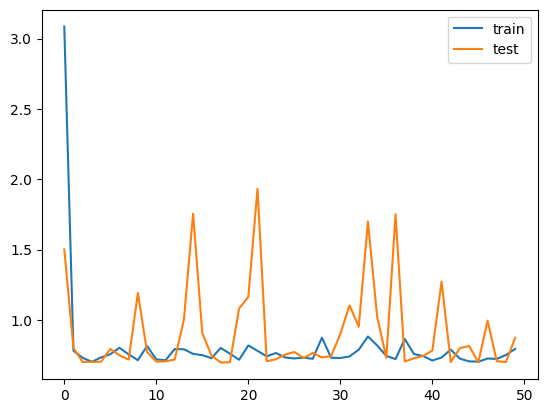

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

1.oui
le modèle apprend trop les données d’entraînement
2. Parce que le modèle complexe
peu de données
bruit dans les données financières

3. NN → faible biais
mais forte variance

PARTIE 8 — EXPÉRIENCE AVANCÉE

In [21]:
X_small = X_train[:100]
y_small = y_train[:100]

In [22]:
# Logistic Regression
model_lr.fit(X_small, y_small)

# Random Forest
rf.fit(X_small, y_small)

# NN
model_nn_small = build_model(X_small.shape[1])
model_nn_small.fit(X_small, y_small, epochs=50, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1. Régression logistique

2. Parceque le modèle est  simple et a peu de paramètres
, est moins sensible aux variations des données

3. LR → faible variance
RF → moyenne variance
NN → forte variance

Plus un modèle est complexe → plus variance élevée

PARTIE 9 — COMPARAISON FINALE

In [23]:

from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, y_pred_lr))
print("RF:", accuracy_score(y_test, y_pred_rf))
print("NN:", accuracy_score(y_test, y_pred_nn))

LR: 0.4925373134328358
RF: 0.5024875621890548
NN: 0.5099502487562189


9.1 Le meilleur modèle est: Random Forest

9.2 Ce n'est pas le NN car:
trop complexe
surapprentissage
données bruitées

9.3 LR → biais élevé, variance faible
RF → bon compromis
NN → faible biais, forte variance

PARTIE 10 — SYNTHÈSE

1) Le problème est difficile car
*   les marchés financiers
≈ aléatoires
*   bruit élevé
*  peu de signal exploitable

2) Le modèle linéaire est limité ar il ne capte pas :

non-linéarités
interactions complexes

3) Le Rôle du feature engineering est le suivant:

enrichir les données
permettre à un modèle simple d’être plus performant

4) Intérêt des réseaux de neurones
* capturent relations complexes
* très flexibles

5) Dangers du surapprentissage
modèle trop adapté au train
mauvaise généralisation
performance trompeuse

6) Choix en production
Random Forest car :
il est stable, bon compromis performance / robustesse

PARTIE 11 — RECHERCHE DU MEILLEUR MODÈLE

11.1 Régression Logistique

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results_lr = []

for C in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results_lr.append((C, acc))

print(results_lr)

[(0.01, 0.4900497512437811), (0.1, 0.4925373134328358), (1, 0.4925373134328358), (10, 0.4900497512437811)]


1) C contrôle la régularisation :

petit C → forte régularisation → modèle simple
grand C → faible régularisation → modèle plus complexe

2) C modifie la généralisation parce que :
trop complexe → surapprentissage
trop simple → sous-apprentissage

Donc C ajuste ce compromis

3)La valeur qui semble meilleure est celle avec la meilleure accuracy


11.2 Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

results_rf = []

for n_estimators in [50, 100, 200, 300]:
    for max_depth in [3, 5, 8, None]:

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results_rf.append((n_estimators, max_depth, acc))

print(results_rf[:10])

[(50, 3, 0.5024875621890548), (50, 5, 0.5099502487562189), (50, 8, 0.5), (50, None, 0.48507462686567165), (100, 3, 0.5074626865671642), (100, 5, 0.4925373134328358), (100, 8, 0.4975124378109453), (100, None, 0.48258706467661694), (200, 3, 0.5099502487562189), (200, 5, 0.48756218905472637)]


1.L'effet de max_depth est:
faible profondeur → modèle simple
grande profondeur → modèle complexe

2. La profondeur trop grande est dangereuse car:
l’arbre mémorise les données, surapprentissage

3. Un équilibre biais / variance

11.3 Réseau de neurones



In [26]:
results_nn = []

for hidden1, hidden2, epochs in [(32,16,20), (64,32,30), (128,64,50)]:

    model = build_model(X_train.shape[1], hidden1, hidden2)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        validation_data=(X_test, y_test),
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]

    results_nn.append((hidden1, hidden2, epochs, val_acc))

print(results_nn)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[(32, 16, 20, 0.5024875402450562), (64, 32, 30, 0.4900497496128082), (128, 64, 50, 0.4900497496128082)]


1. Les effets des neurones sont:
plus de neurones → plus de capacité
mais → risque de surapprentissage

2. Effet des epochs

plus d’epochs → meilleur apprentissage
mais trop → surapprentissage

3. On surapprend lorsque

performance train monte
performance validation descend